In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from utils import data_loader_utils
import itertools

In [2]:
machines = ["M01", "M02", "M03"]
process_names = [
    "OP00",
    "OP01",
    "OP02",
    "OP03",
    "OP04",
    "OP05",
    "OP06",
    "OP07",
    "OP08",
    "OP09",
    "OP10",
    "OP11",
    "OP12",
    "OP13",
    "OP14",
]
labels = ["good", "bad"]
path_to_dataset = Path("../data/").absolute()

In [3]:
def data_generator():
    for process_name, machine, label in itertools.product(
        process_names, machines, labels
    ):
        data_path = os.path.join(path_to_dataset, machine, process_name, label)
        data_list, data_label = data_loader_utils.load_tool_research_data(
            data_path, label=label, verbose=False
        )

        for data_array, label_ in zip(data_list, data_label):
            # Break apart the label_
            # Example label_: M01_Aug_2019_OP00_000_good
            # Get M01, *, OP00, 000, good
            label_parts = label_.split("_")
            machine_id = label_parts[0]
            tool_operation_date = label_parts[1] + "_" + label_parts[2]
            tool_operation_id = label_parts[3]
            tool_operation_instance = int(label_parts[4])
            tool_operation_status = label_parts[5]

            yield [
                machine_id,
                tool_operation_id,
                tool_operation_instance,
                tool_operation_date,
                tool_operation_status,
                label_,
                data_array.astype(np.int16),
            ]


df = pd.DataFrame(
    data_generator(),
    columns=[
        "machine_id",
        "tool_operation_id",
        "tool_operation_instance",
        "tool_operation_date",
        "tool_operation_status",
        "label",
        "vibration_data",
    ],
)

display(df.head())
print(f"There are {len(df)} labeled samples of vibration data in the dataset.")

,machine_id,tool_operation_id,tool_operation_instance,tool_operation_date,tool_operation_status,label,vibration_data
0,M01,OP00,0,Aug_2019,good,M01_Aug_2019_OP00_000_good,"[[-9, 9, -1011], [-21, 19, -1011], [-15, 23, -..."
1,M01,OP00,1,Aug_2019,good,M01_Aug_2019_OP00_001_good,"[[-15, 21, -1009], [-13, 23, -1013], [-13, 19,..."
2,M01,OP00,3,Aug_2019,good,M01_Aug_2019_OP00_003_good,"[[-9, 15, -1018], [-27, 15, -1005], [-13, 21, ..."
3,M01,OP00,4,Aug_2019,good,M01_Aug_2019_OP00_004_good,"[[-33, 15, -1005], [-37, 7, -1011], [-35, 21, ..."
4,M01,OP00,5,Aug_2019,good,M01_Aug_2019_OP00_005_good,"[[-5, 17, -1016], [-17, 23, -1018], [-7, 42, -..."


There are 1702 labeled samples of vibration data in the dataset.


Each sample contains the following data:

- `machine_id`: Identifier for the CNC machine (M01, M02, or M03)
- `tool_operation_id`: Identifier for the tool operation (OP00 through OP14)
- `tool_operation_instance`: Instance number of the tool operation for the given machine and date
- `tool_operation_date`: Date the tool operation was performed (e.g., Aug_2019)
- `tool_operation_status`: Status of the tool operation (good or bad)
- `label`: Combined label of the above fields for easy identification
- `vibration_data`: Numpy array of vibration data collected during the tool operation
  - These are x,y,z axis vibration data sampled at 2 kHz from a tri-axial CISS sensor


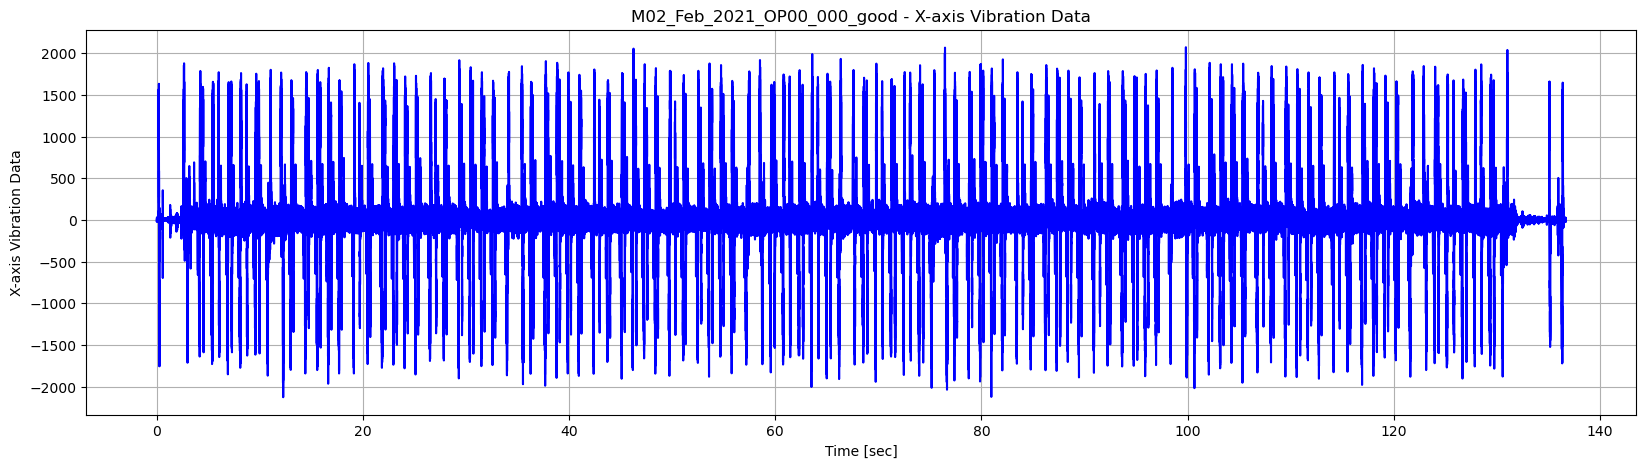

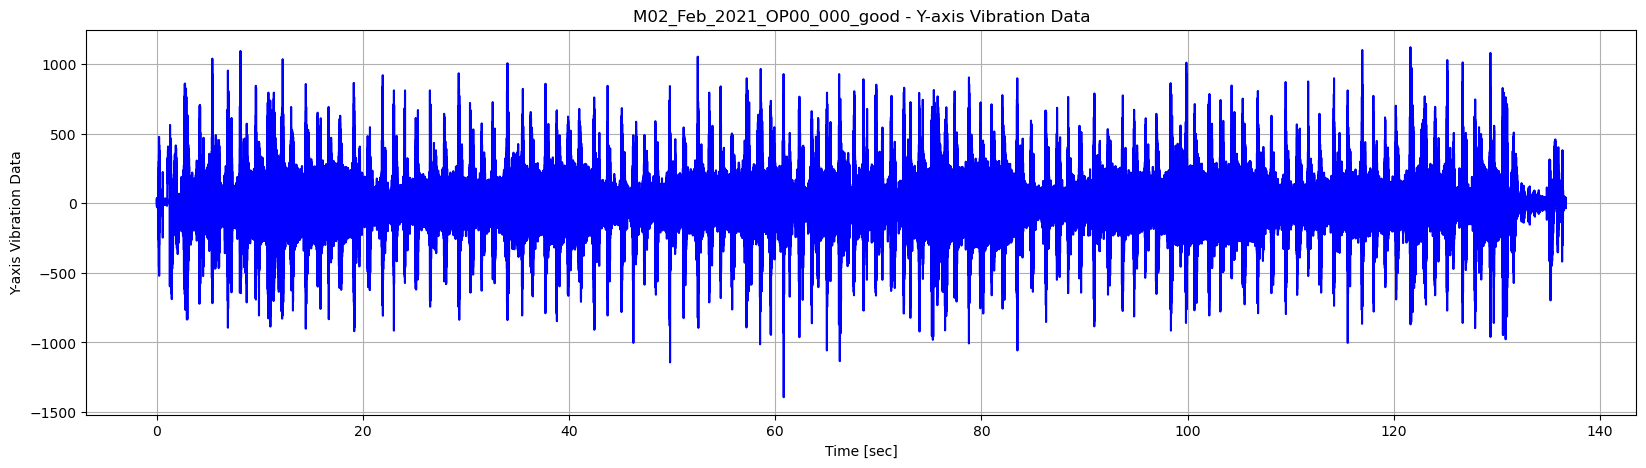

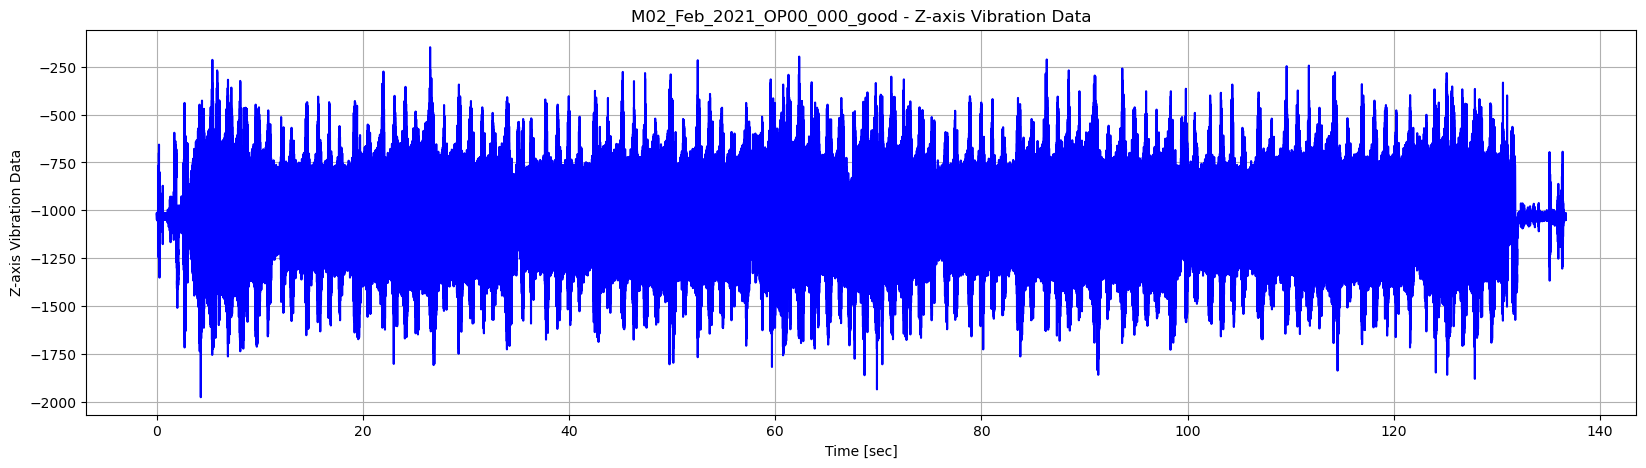

In [4]:
# plot good sample for reference
good_row = df[
    (df["machine_id"] == "M02")
    & (df["tool_operation_status"] == "good")
    & (df["tool_operation_id"] == "OP00")
    & (df["tool_operation_instance"] == 0)
    & (df["tool_operation_date"] == "Feb_2021")
].iloc[0]

data_loader_utils.plot_vibration_data(
    good_row["vibration_data"], label=good_row["label"]
)

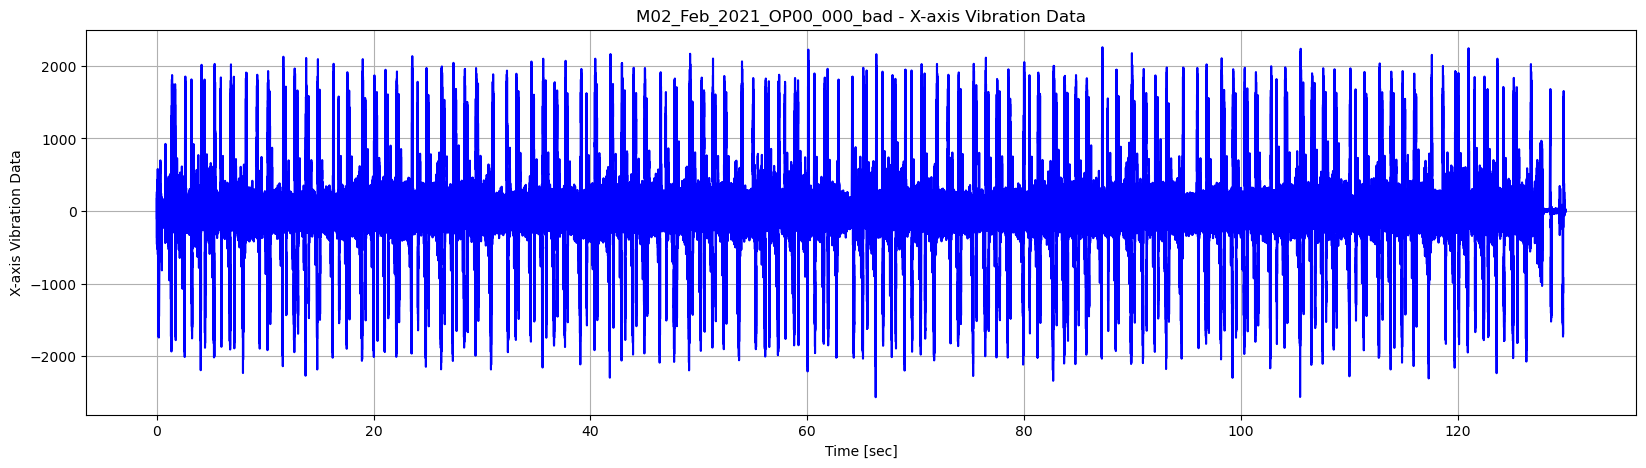

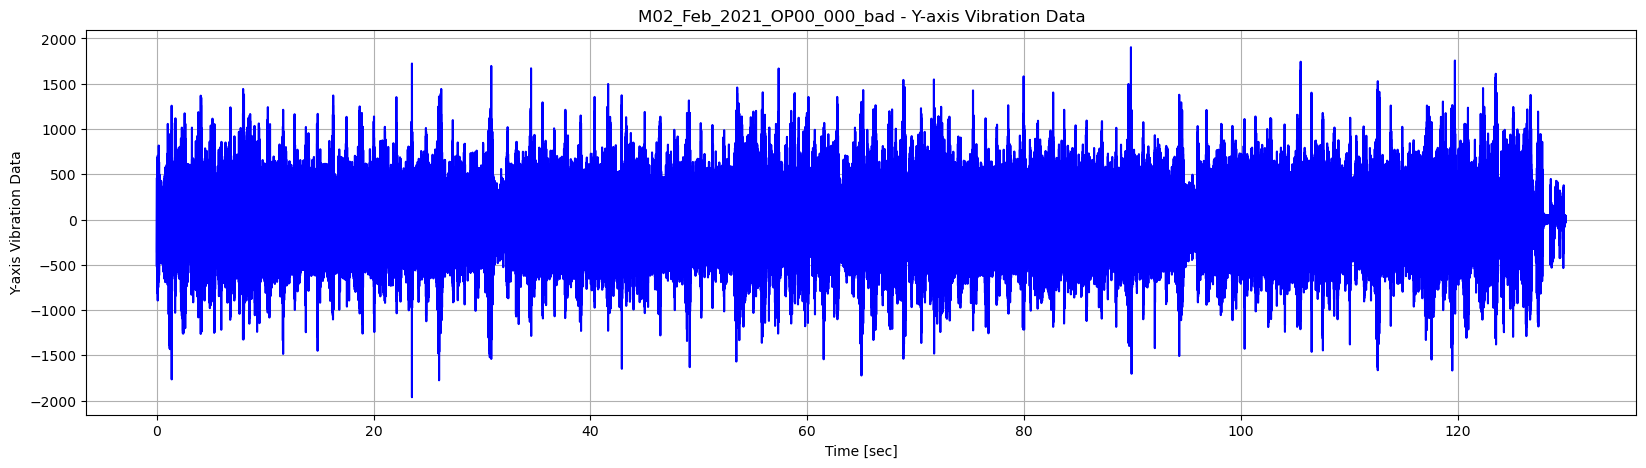

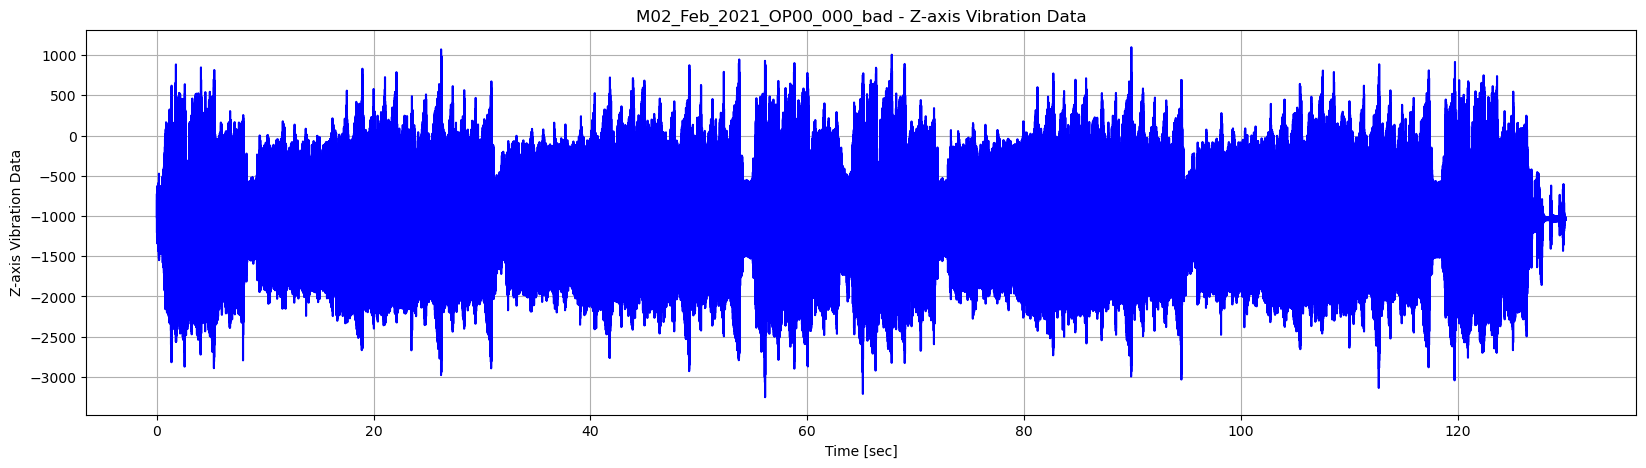

In [5]:
# plot bad sample for reference
bad_row = df[
    (df["machine_id"] == "M02")
    & (df["tool_operation_status"] == "bad")
    & (df["tool_operation_id"] == "OP00")
    & (df["tool_operation_instance"] == 0)
    & (df["tool_operation_date"] == "Feb_2021")
].iloc[0]

data_loader_utils.plot_vibration_data(bad_row["vibration_data"], label=bad_row["label"])